# MLB 2025 Analytics: Attendance, Jerseys, and Performance

Exploring correlations between:
- Attendance and team performance
- Jersey choices and attendance
- Day/night games and scoring
- Day of week effects
- Uniform selection strategy


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## Load Data


In [11]:
# Load the complete dataset
df = pd.read_csv('mlb_2025_complete_dataset.csv')

# Parse dates
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
df['is_weekend'] = df['day_of_week'].isin(['Friday', 'Saturday', 'Sunday'])

# Calculate total runs
df['total_runs'] = df['home_score'] + df['away_score']

print(f"Dataset shape: {df.shape}")
print(f"\nCompleted games: {(df['status'] == 'Final').sum()}")
print(f"Games with attendance: {df['attendance'].notna().sum()}")
df.head()


Dataset shape: (2430, 46)

Completed games: 2425
Games with attendance: 2430


,gamePk,date,gameDate,season,gameType,status,statusCode,home_team_id,home_team_name,home_score,...,home_cap,home_jersey_code,away_jersey,away_pants,away_cap,away_jersey_code,day_of_week,month,is_weekend,total_runs
0,778563,2025-03-18,2025-03-18T10:10:00Z,2025,R,Final,F,112,Chicago Cubs,1.0,...,Cubs Primary Blue Hat,112_jersey_1_2025,"Dodgers Alt Road Grey ""Dodgers"" Jersey",Dodgers Road Grey Pants,Dodgers Primary Blue Hat,119_jersey_3_2025,Tuesday,March,False,5.0
1,778564,2025-03-19,2025-03-19T10:10:00Z,2025,R,Final,F,112,Chicago Cubs,3.0,...,Cubs Primary Blue Hat,112_jersey_2_2025,Dodgers Home White Jersey,Dodgers Home White Pants,Dodgers Primary Blue Hat,119_jersey_1_2025,Wednesday,March,False,9.0
2,778557,2025-03-27,2025-03-27T19:05:00Z,2025,R,Final,F,147,New York Yankees,4.0,...,Yankees Primary Navy Hat,147_jersey_1_2025,Brewers Alt Blue Jersey,Brewers Road Grey Pants,Brewers Alt Yellow Front Hat,158_jersey_4_2025,Thursday,March,False,6.0
3,778556,2025-03-27,2025-03-27T19:07:00Z,2025,R,Final,F,141,Toronto Blue Jays,2.0,...,Blue Jays Primary All Blue Hat,141_jersey_1_2025,Orioles Alt Black Jersey,Orioles Away Grey Pants,"Orioles Alt Black Front Orange Bill ""O's"" Hat",110_jersey_3_2025,Thursday,March,False,14.0
4,778545,2025-03-27,2025-03-27T20:10:00Z,2025,R,Final,F,135,San Diego Padres,7.0,...,Padres Primary All Brown Hat,135_jersey_1_2025,Braves Road Grey Jersey,Braves Road Grey Pants,Braves Alt All Navy Hat,144_jersey_2_2025,Thursday,March,False,11.0


## Attendance Leaderboards


In [12]:
# Team attendance statistics
team_attendance = df.groupby('home_team_name').agg({
    'attendance': ['mean', 'sum', 'count'],
    'home_is_winner': 'mean'
}).round(0)

team_attendance.columns = ['avg_attendance', 'total_attendance', 'home_games', 'win_pct']
team_attendance = team_attendance.sort_values('avg_attendance', ascending=False)

print("=" * 60)
print("ATTENDANCE LEADERBOARD")
print("=" * 60)
print(team_attendance.head(10).to_string())

# Worst attendance
print("\n" + "=" * 60)
print("LOWEST ATTENDANCE")
print("=" * 60)
print(team_attendance.tail(5).to_string())


ATTENDANCE LEADERBOARD
                       avg_attendance  total_attendance  home_games  win_pct
home_team_name                                                              
Los Angeles Dodgers           49537.0         4012470.0          81      1.0
San Diego Padres              42435.0         3437201.0          81      1.0
New York Yankees              42426.0         3436483.0          81      1.0
Philadelphia Phillies         41672.0         3375457.0          81      1.0
New York Mets                 39316.0         3184570.0          81      1.0
Chicago Cubs                  37259.0         3017983.0          81      1.0
San Francisco Giants          36121.0         2925823.0          81      1.0
Atlanta Braves                35842.0         2903167.0          81      0.0
Toronto Blue Jays             35184.0         2849935.0          81      1.0
Boston Red Sox                34321.0         2779986.0          81      1.0

LOWEST ATTENDANCE
                    avg_attendance

## Attendance vs Team Performance


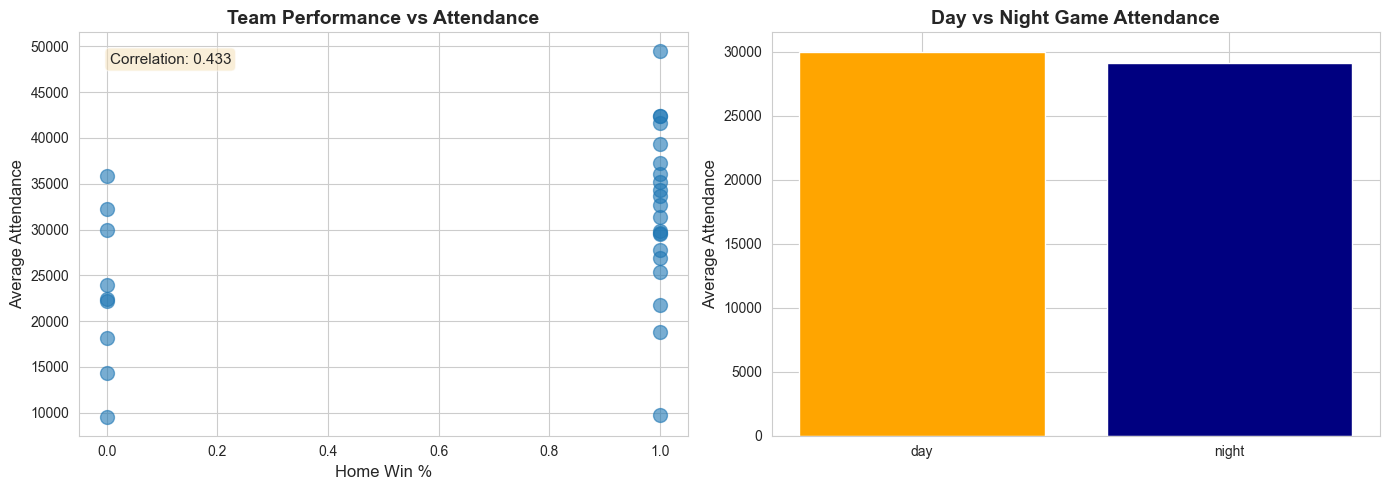


Correlation between win % and attendance: 0.433

Day/Night Attendance:
dayNight
day      30017.153762
night    29116.371447


In [13]:
# Does winning correlate with attendance?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Win % vs Avg Attendance
axes[0].scatter(team_attendance['win_pct'], team_attendance['avg_attendance'], s=100, alpha=0.6)
axes[0].set_xlabel('Home Win %', fontsize=12)
axes[0].set_ylabel('Average Attendance', fontsize=12)
axes[0].set_title('Team Performance vs Attendance', fontsize=14, fontweight='bold')

# Add correlation
corr = team_attendance['win_pct'].corr(team_attendance['avg_attendance'])
axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Day/Night attendance
day_night = df.groupby('dayNight')['attendance'].mean().sort_values(ascending=False)
axes[1].bar(range(len(day_night)), day_night.values, color=['orange', 'navy'])
axes[1].set_xticks(range(len(day_night)))
axes[1].set_xticklabels(day_night.index)
axes[1].set_ylabel('Average Attendance', fontsize=12)
axes[1].set_title('Day vs Night Game Attendance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCorrelation between win % and attendance: {corr:.3f}")
print(f"\nDay/Night Attendance:")
print(day_night.to_string())


## Day of Week Analysis


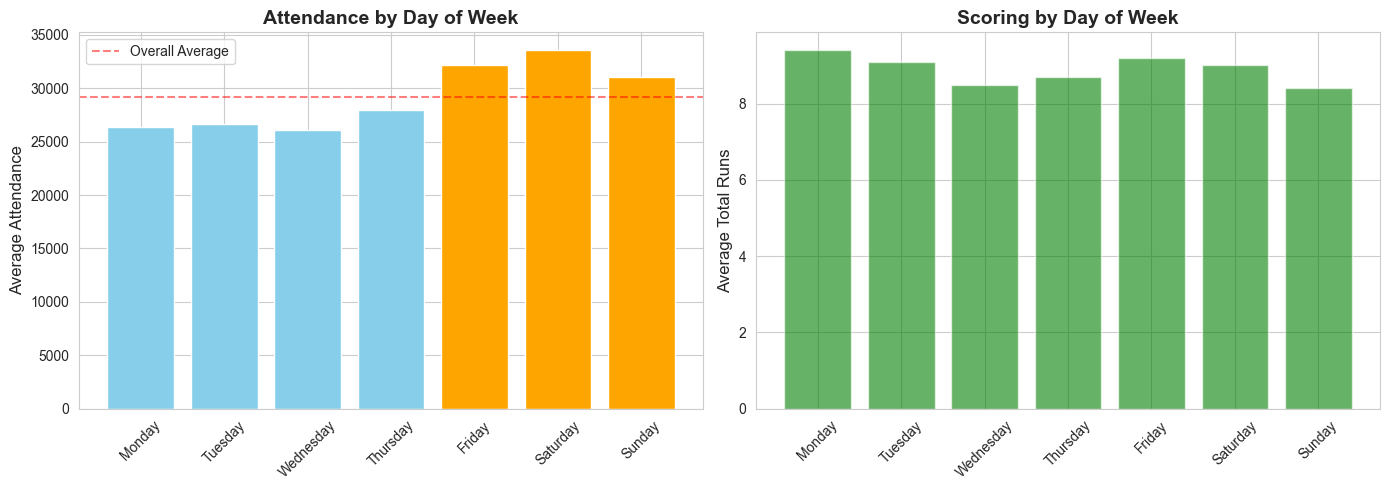


Day of Week Statistics:
             avg_attendance  games  avg_runs
day_of_week                                 
Monday              26396.8    259       9.4
Tuesday             26645.9    368       9.1
Wednesday           26123.7    375       8.5
Thursday            27925.9    222       8.7
Friday              32216.7    393       9.2
Saturday            33554.7    407       9.0
Sunday              31089.9    406       8.4


In [14]:
# Day of week patterns
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = df.groupby('day_of_week').agg({
    'attendance': ['mean', 'count'],
    'total_runs': 'mean'
}).round(1)
dow_stats.columns = ['avg_attendance', 'games', 'avg_runs']
dow_stats = dow_stats.reindex(day_order)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attendance by day
axes[0].bar(range(7), dow_stats['avg_attendance'], color=['skyblue']*4 + ['orange']*3)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_order, rotation=45)
axes[0].set_ylabel('Average Attendance', fontsize=12)
axes[0].set_title('Attendance by Day of Week', fontsize=14, fontweight='bold')
axes[0].axhline(dow_stats['avg_attendance'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall Average')
axes[0].legend()

# Runs by day
axes[1].bar(range(7), dow_stats['avg_runs'], color='green', alpha=0.6)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_order, rotation=45)
axes[1].set_ylabel('Average Total Runs', fontsize=12)
axes[1].set_title('Scoring by Day of Week', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDay of Week Statistics:")
print(dow_stats.to_string())


## Jersey Analysis: Do Uniforms Affect Attendance?


In [15]:
# Analyze top jerseys by attendance
jersey_attendance = df.groupby('home_jersey').agg({
    'attendance': ['mean', 'count'],
    'home_score': 'mean',
    'home_is_winner': 'mean',
    'is_weekend': 'mean'
}).round(1)

jersey_attendance.columns = ['avg_attendance', 'games_worn', 'avg_home_score', 'win_pct', 'pct_weekend']

# Filter jerseys worn at least 5 times
popular_jerseys = jersey_attendance[jersey_attendance['games_worn'] >= 5].copy()
popular_jerseys = popular_jerseys.sort_values('avg_attendance', ascending=False)

print("=" * 80)
print("TOP JERSEYS BY ATTENDANCE (worn 5+ times)")
print("=" * 80)
print(popular_jerseys.head(15).to_string())

print("\n" + "=" * 80)
print("LOWEST ATTENDANCE JERSEYS (worn 5+ times)")
print("=" * 80)
print(popular_jerseys.tail(10).to_string())


TOP JERSEYS BY ATTENDANCE (worn 5+ times)
                                    avg_attendance  games_worn  avg_home_score  win_pct  pct_weekend
home_jersey                                                                                         
Dodgers City Connect Jersey                51396.0          10             7.4      0.6          1.0
Dodgers Home White Jersey                  49172.3          69             5.2      0.6          0.4
Padres City Connect Jersey                 43354.0          11             3.7      0.6          1.0
Padres Alt Sand Camoflauge Jersey          42999.9          14             4.8      0.7          1.0
Phillies Alt Cream Jersey                  42922.1          22             4.8      0.5          0.8
Phillies City Connect Jersey               42514.8          13             5.2      0.8          1.0
Yankees Home Pinstripe Jersey              42425.7          81             5.0      0.6          0.5
Padres Home White Pinstripe Jersey         42085.

## Team-Specific Jersey Analysis


Analyzing: Los Angeles Dodgers

Los Angeles Dodgers Jersey Performance:
                              avg_attendance  times_worn  avg_score  win_pct  pct_weekend  pct_night
home_jersey                                                                                         
Dodgers "Gold Series" Jersey         52812.0           2        6.5      1.0          0.5        0.5
Dodgers City Connect Jersey          51396.0          10        7.4      0.6          1.0        0.8
Dodgers Home White Jersey            49172.3          69        5.2      0.6          0.4        0.8


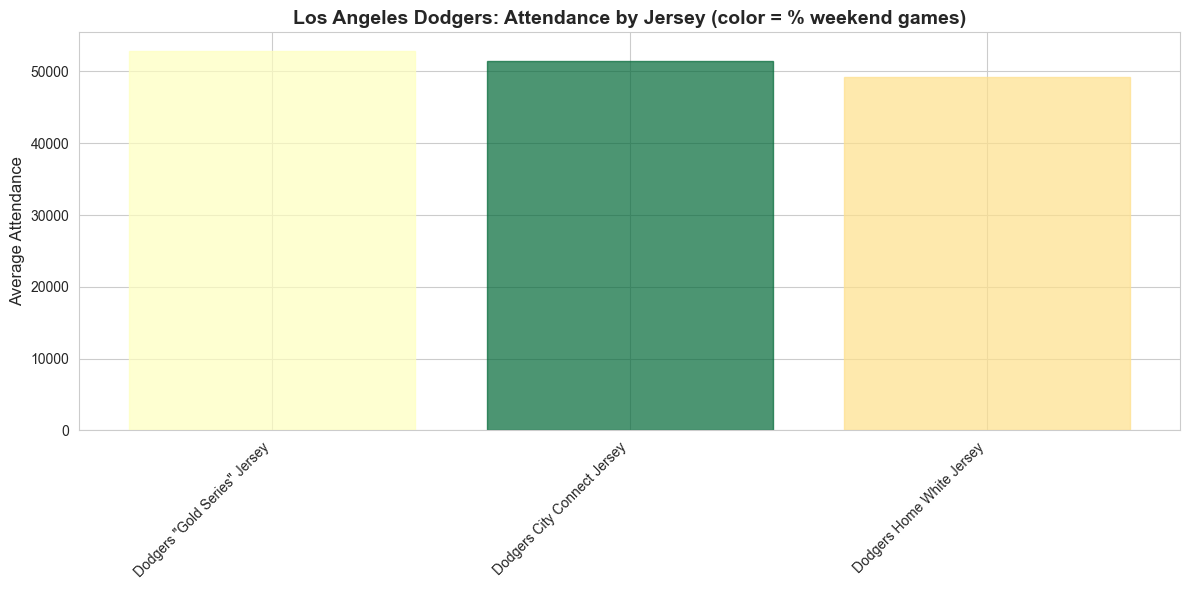

In [16]:
# Pick a high-attendance team to analyze
top_team = team_attendance.index[0]
print(f"Analyzing: {top_team}")
print("=" * 60)

team_data = df[df['home_team_name'] == top_team].copy()
team_jerseys = team_data.groupby('home_jersey').agg({
    'attendance': ['mean', 'count'],
    'home_score': 'mean',
    'home_is_winner': 'mean',
    'is_weekend': 'mean',
    'dayNight': lambda x: (x == 'night').mean()
}).round(1)

team_jerseys.columns = ['avg_attendance', 'times_worn', 'avg_score', 'win_pct', 'pct_weekend', 'pct_night']
team_jerseys = team_jerseys.sort_values('avg_attendance', ascending=False)

print(f"\n{top_team} Jersey Performance:")
print(team_jerseys.to_string())

# Visualize
if len(team_jerseys) > 1:
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(team_jerseys))
    
    # Bar chart
    bars = ax.bar(x, team_jerseys['avg_attendance'], alpha=0.7)
    
    # Color by weekend percentage
    colors = plt.cm.RdYlGn(team_jerseys['pct_weekend'])
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    ax.set_xticks(x)
    ax.set_xticklabels(team_jerseys.index, rotation=45, ha='right')
    ax.set_ylabel('Average Attendance', fontsize=12)
    ax.set_title(f'{top_team}: Attendance by Jersey (color = % weekend games)', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


## Do Jerseys Affect Performance?


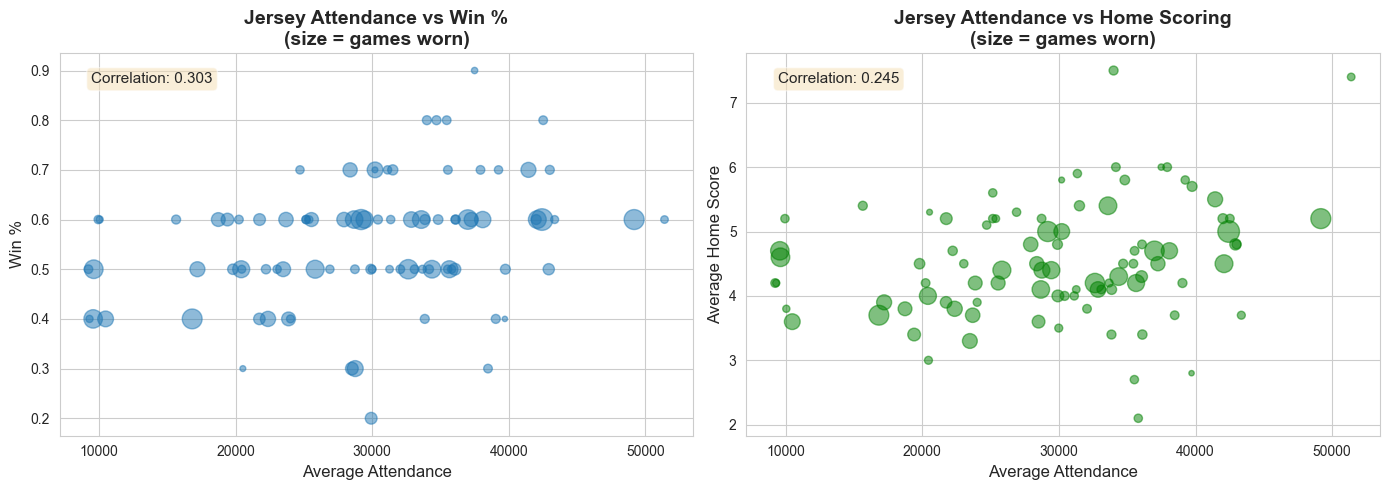


Key Findings:
- Attendance vs Win %: 0.303
- Attendance vs Scoring: 0.245


In [17]:
# Correlation: Jersey attendance vs scoring/winning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter to jerseys worn 5+ times for statistical significance
significant_jerseys = popular_jerseys.copy()

# Attendance vs Win %
axes[0].scatter(significant_jerseys['avg_attendance'], 
                significant_jerseys['win_pct'], 
                s=significant_jerseys['games_worn']*3, 
                alpha=0.5)
axes[0].set_xlabel('Average Attendance', fontsize=12)
axes[0].set_ylabel('Win %', fontsize=12)
axes[0].set_title('Jersey Attendance vs Win %\n(size = games worn)', 
                  fontsize=14, fontweight='bold')

corr1 = significant_jerseys['avg_attendance'].corr(significant_jerseys['win_pct'])
axes[0].text(0.05, 0.95, f'Correlation: {corr1:.3f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Attendance vs Scoring
axes[1].scatter(significant_jerseys['avg_attendance'], 
                significant_jerseys['avg_home_score'], 
                s=significant_jerseys['games_worn']*3, 
                alpha=0.5, color='green')
axes[1].set_xlabel('Average Attendance', fontsize=12)
axes[1].set_ylabel('Average Home Score', fontsize=12)
axes[1].set_title('Jersey Attendance vs Home Scoring\n(size = games worn)', 
                  fontsize=14, fontweight='bold')

corr2 = significant_jerseys['avg_attendance'].corr(significant_jerseys['avg_home_score'])
axes[1].text(0.05, 0.95, f'Correlation: {corr2:.3f}', 
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nKey Findings:")
print(f"- Attendance vs Win %: {corr1:.3f}")
print(f"- Attendance vs Scoring: {corr2:.3f}")


## Confounding Variables: Weekend vs Jersey Choice


In [18]:
# Are special jerseys strategically worn on weekends?
print("=" * 60)
print("INVESTIGATING: Jersey Selection Strategy")
print("=" * 60)

# Check if high-attendance jerseys are worn more on weekends
print(f"\nOverall weekend game rate: {df['is_weekend'].mean():.1%}")
print(f"\nTop 10 attendance jerseys - weekend game rate:")

top_10_jerseys = popular_jerseys.head(10)
for jersey, row in top_10_jerseys.iterrows():
    print(f"  {jersey[:50]:50s} | Weekend: {row['pct_weekend']:.1%} | Games: {int(row['games_worn'])}")

print(f"\nBottom 10 attendance jerseys - weekend game rate:")
bottom_10_jerseys = popular_jerseys.tail(10)
for jersey, row in bottom_10_jerseys.iterrows():
    print(f"  {jersey[:50]:50s} | Weekend: {row['pct_weekend']:.1%} | Games: {int(row['games_worn'])}")

# Statistical test
print(f"\n" + "=" * 60)
print(f"Average weekend rate for TOP 10 jerseys: {top_10_jerseys['pct_weekend'].mean():.1%}")
print(f"Average weekend rate for BOTTOM 10 jerseys: {bottom_10_jerseys['pct_weekend'].mean():.1%}")
print(f"\nThis suggests {'STRONG' if abs(top_10_jerseys['pct_weekend'].mean() - bottom_10_jerseys['pct_weekend'].mean()) > 0.15 else 'some'} confounding!")
print("Teams may be strategically wearing popular jerseys on high-attendance days.")


INVESTIGATING: Jersey Selection Strategy

Overall weekend game rate: 49.6%

Top 10 attendance jerseys - weekend game rate:
  Dodgers City Connect Jersey                        | Weekend: 100.0% | Games: 10
  Dodgers Home White Jersey                          | Weekend: 40.0% | Games: 69
  Padres City Connect Jersey                         | Weekend: 100.0% | Games: 11
  Padres Alt Sand Camoflauge Jersey                  | Weekend: 100.0% | Games: 14
  Phillies Alt Cream Jersey                          | Weekend: 80.0% | Games: 22
  Phillies City Connect Jersey                       | Weekend: 100.0% | Games: 13
  Yankees Home Pinstripe Jersey                      | Weekend: 50.0% | Games: 81
  Padres Home White Pinstripe Jersey                 | Weekend: 30.0% | Games: 55
  Mets City Connect Jersey                           | Weekend: 90.0% | Games: 17
  Phillies Home Pinstripe Jersey                     | Weekend: 30.0% | Games: 39

Bottom 10 attendance jerseys - weekend game rate:
  

## Next Steps for Tomorrow

Ideas to explore:
1. **Control for confounders**: Use regression to isolate jersey effect controlling for day of week, opponent quality, etc.
2. **Alternative jerseys**: Which teams have the most jersey variety? Does variety correlate with attendance?
3. **Opponent effect**: Do certain matchups drive attendance regardless of jersey?
4. **Time trends**: Do attendance patterns change throughout the season?
5. **Jersey "luck"**: Are there jerseys teams wear when they're on winning/losing streaks?
6. **Home vs Away patterns**: Analyze away team jerseys and their correlation with travel distance/performance
